# EXAFS Shell Fitting — Bulk Fe K-edge

Parse feffit report files, extract interatomic distances, and plot:
1. R (Reff + ΔR) box plots by station
2. R depth profiles with error bars
3. Literature comparison (beeswarm + box plots)

**Inputs:**
- `bulk/feffit_reports/*.txt` — Larch feffit report files
- `Fe_EXAFS_params_merged.csv` — literature EXAFS distances

**Outputs:**
- `bulk/feffit_parameters.csv` — parsed fit parameters
- `bulk/R_boxplots.{png,pdf}` — box plots of R by station
- `bulk/R_depth_profiles.{png,pdf}` — R vs depth profiles
- `figure_exafs_distances.{png,pdf}` — literature comparison

## Imports and configuration

In [ ]:
import re
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from collections import defaultdict
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

DPI = 300
TARGET_WIDTH_MM = 180
TARGET_WIDTH_IN = TARGET_WIDTH_MM / 25.4

REPORT_DIR = Path("bulk/feffit_reports")
OUT_DIR = Path("bulk")
PARAMS_CSV = OUT_DIR / "feffit_parameters.csv"

FIGURE_DIR = Path("dewey-etal_gp17-sediments/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SHELLS = ["O203", "Mg302", "Si328"]
SHELL_LABELS = {"O203": "Fe\u2013O", "Mg302": "Fe\u2013Mg", "Si328": "Fe\u2013Si"}
SHELL_COLORS = {"O203": "#1f77b4", "Mg302": "#d62728", "Si328": "#2ca02c"}

STATIONS = [5, 15, 27]
STATION_LABELS = {5: "Station 5", 15: "Station 15", 27: "Station 27"}
STATION_LABELS_SHORT = {5: "Stn 5", 15: "Stn 15", 27: "Stn 27"}

---
## 1. Parse feffit reports

Read all report files in `bulk/feffit_reports/` and extract fit statistics,
shell parameters (N, ΔR, σ²), and compute R = Reff + ΔR.

In [2]:
def parse_sample_name(filename):
    """Extract sample name from report filename.
    e.g. 'GP17_station5_19119_1cm_015_A_fl_avg_csv_Mar-07_23_55.txt'
      -> 'GP17_station5_19119_1cm'
    """
    m = re.match(r"(GP17_station\d+_\d+_\d+cm)", filename)
    if m:
        return m.group(1)
    return filename


def parse_report(filepath):
    """Parse a single feffit report file and return a dict of parameters."""
    text = filepath.read_text()
    result = {}

    # Statistics
    for key, pattern in [
        ("chi_sq", r"chi_square\s+=\s+([\d.eE+-]+)"),
        ("red_chi_sq", r"reduced chi_square\s+=\s+([\d.eE+-]+)"),
        ("r_factor", r"r-factor\s+=\s+([\d.eE+-]+)"),
    ]:
        m = re.search(pattern, text)
        if m:
            result[key] = float(m.group(1))

    # Parameters
    param_pattern = re.compile(
        r"^\s+([\w]+)\s+=\s+([\d.eE+-]+)\s+\+/-\s+([\d.eE+-]+)", re.MULTILINE
    )
    fixed_pattern = re.compile(
        r"^\s+([\w]+)\s+=\s+([\d.eE+-]+)\s+\(fixed\)", re.MULTILINE
    )

    params = {}
    for m in param_pattern.finditer(text):
        params[m.group(1)] = (float(m.group(2)), float(m.group(3)))
    for m in fixed_pattern.finditer(text):
        params[m.group(1)] = (float(m.group(2)), None)

    if "s02" in params:
        result["s02"] = params["s02"][0]
    if "e0" in params:
        result["e0"] = params["e0"][0]
        result["e0_uncert"] = params["e0"][1]

    for shell in SHELLS:
        for prefix in ["N", "delr", "sigma2"]:
            key = f"{prefix}_{shell}"
            if key in params:
                result[key] = params[key][0]
                result[f"{key}_uncert"] = params[key][1]

    # Reff from [[Paths]] section
    path_blocks = re.split(r"= Path '(Fe_\w+)'", text)
    for i in range(1, len(path_blocks) - 1, 2):
        shell = path_blocks[i].replace("Fe_", "")
        if shell in SHELLS:
            reff_m = re.search(r"reff\s+=\s+([\d.eE+-]+)", path_blocks[i + 1])
            if reff_m:
                reff = float(reff_m.group(1))
                result[f"Reff_{shell}"] = reff
                delr_key = f"delr_{shell}"
                if delr_key in result:
                    result[f"R_{shell}"] = reff + result[delr_key]
                    result[f"R_{shell}_uncert"] = result.get(f"{delr_key}_uncert")

    return result

In [3]:
# Parse all reports and build CSV
reports = sorted(REPORT_DIR.glob("*.txt"))
# Exclude chikw and chir_mag fit data files
reports = [r for r in reports if "_chikw" not in r.name and "_chir_mag" not in r.name]
print(f"Found {len(reports)} report files")

rows = []
for rpt in reports:
    params = parse_report(rpt)
    params["sample"] = parse_sample_name(rpt.name)
    rows.append(params)

# Sort by station then depth
def sort_key(row):
    m = re.match(r"GP17_station(\d+)_\d+_(\d+)cm", row["sample"])
    if m:
        return (int(m.group(1)), int(m.group(2)))
    return (999, 999)

rows.sort(key=sort_key)

# Build column order
columns = ["sample", "s02", "e0", "e0_uncert"]
for shell in SHELLS:
    for col in [f"N_{shell}", f"N_{shell}_uncert",
                f"delr_{shell}", f"delr_{shell}_uncert",
                f"sigma2_{shell}", f"sigma2_{shell}_uncert",
                f"Reff_{shell}", f"R_{shell}", f"R_{shell}_uncert"]:
        columns.append(col)
columns.extend(["chi_sq", "red_chi_sq", "r_factor"])

with open(PARAMS_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=columns, extrasaction="ignore")
    writer.writeheader()
    writer.writerows(rows)

print(f"Wrote {len(rows)} rows to {PARAMS_CSV}")

# Load back as DataFrame for subsequent plots
df_params = pd.read_csv(PARAMS_CSV)
df_params["station"] = df_params["sample"].apply(lambda s: int(re.search(r"station(\d+)", s).group(1)))
df_params["depth_cm"] = df_params["sample"].apply(lambda s: int(re.search(r"_(\d+)cm", s).group(1)))
df_params.head()

Found 21 report files
Wrote 21 rows to bulk/feffit_parameters.csv


,sample,s02,e0,e0_uncert,N_O203,N_O203_uncert,delr_O203,delr_O203_uncert,sigma2_O203,sigma2_O203_uncert,...,sigma2_Si328,sigma2_Si328_uncert,Reff_Si328,R_Si328,R_Si328_uncert,chi_sq,red_chi_sq,r_factor,station,depth_cm
0,GP17_station5_19119_1cm,0.7,6.998451,1.445132,6.055335,0.711398,0.000961,0.009448,0.009433,0.001366,...,0.001,0.000070,3.2788,3.276684,0.016048,8.495151,0.560376,0.027504,5,1
1,GP17_station5_19119_3cm,0.7,6.726903,1.287801,5.971410,0.613593,-0.006302,0.008006,0.008212,0.001126,...,0.001,0.000265,3.2788,3.271463,0.008513,8.018827,0.528956,0.021620,5,3
2,GP17_station5_19119_5cm,0.7,6.291782,1.255695,5.990241,0.584291,-0.012453,0.007664,0.007970,0.001055,...,0.001,0.000411,3.2788,3.264459,0.009624,12.547193,0.827667,0.019682,5,5
3,GP17_station5_19119_7cm,0.7,6.645571,1.261105,6.063885,0.598750,-0.009166,0.007746,0.008006,0.001074,...,0.001,0.000084,3.2788,3.267339,0.010674,8.328780,0.549402,0.020636,5,7
4,GP17_station5_19119_9cm,0.7,6.887321,1.273200,5.717654,0.564333,-0.006228,0.007671,0.007384,0.001047,...,0.001,0.000033,3.2788,3.271237,0.015898,13.116203,0.865201,0.020648,5,9


---
## 2. R box plots by station

Box-and-whisker plots of fitted R (Reff + ΔR) for each scattering path,
with individual sample points overlaid.

Saved to bulk/R_boxplots.{png,pdf}


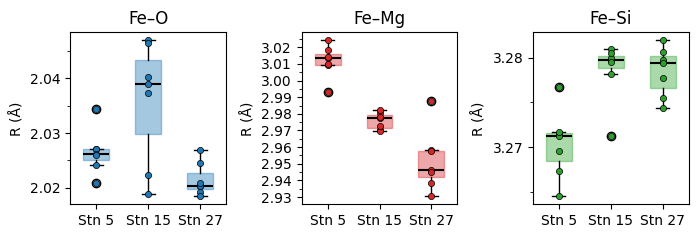

In [4]:
fig, axes = plt.subplots(
    1, len(SHELLS),
    figsize=(TARGET_WIDTH_IN, TARGET_WIDTH_IN * 0.35),
)

for ax, shell in zip(axes, SHELLS):
    data = [df_params.loc[df_params["station"] == stn, f"R_{shell}"] for stn in STATIONS]
    tick_labels = [STATION_LABELS_SHORT[s] for s in STATIONS]
    c = SHELL_COLORS[shell]

    bp = ax.boxplot(
        data,
        tick_labels=tick_labels,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(c)
        patch.set_alpha(0.4)
        patch.set_edgecolor(c)

    for i, stn in enumerate(STATIONS):
        vals = df_params.loc[df_params["station"] == stn, f"R_{shell}"]
        ax.scatter(
            [i + 1] * len(vals), vals,
            color=c, edgecolor="black", linewidth=0.5,
            s=20, zorder=3,
        )

    ax.set_title(SHELL_LABELS[shell])
    ax.set_ylabel("R (\u00c5)")
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.01))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.005))

fig.tight_layout()
for fmt in ("png", "pdf"):
    fig.savefig(FIGURE_DIR / f"R_boxplots.{fmt}", dpi=DPI, bbox_inches="tight")
print(f"Saved to {FIGURE_DIR}/R_boxplots.{{png,pdf}}")
plt.show()

---
## 3. R depth profiles

Fitted R vs depth for each scattering path, one panel per station.
Error bars from ΔR uncertainty.

Saved to bulk/R_depth_profiles.{png,pdf}


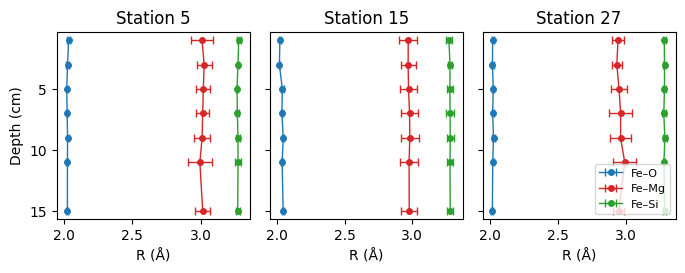

In [5]:
stations = sorted(df_params["station"].unique())
n_stations = len(stations)

fig, axes = plt.subplots(
    1, n_stations,
    figsize=(TARGET_WIDTH_IN, TARGET_WIDTH_IN * 0.4),
    sharey=True,
)
if n_stations == 1:
    axes = [axes]

for ax, stn in zip(axes, stations):
    sub = df_params[df_params["station"] == stn].sort_values("depth_cm")

    for shell in SHELLS:
        ax.errorbar(
            sub[f"R_{shell}"],
            sub["depth_cm"],
            xerr=sub[f"R_{shell}_uncert"],
            fmt="o-",
            color=SHELL_COLORS[shell],
            label=SHELL_LABELS[shell],
            capsize=3,
            markersize=4,
            linewidth=1,
        )

    ax.set_title(STATION_LABELS.get(stn, f"Station {stn}"))
    ax.set_xlabel("R (\u00c5)")
    ax.invert_yaxis()

axes[0].set_ylabel("Depth (cm)")
axes[-1].legend(loc="lower right", fontsize=8)

fig.tight_layout()
for fmt in ("png", "pdf"):
    fig.savefig(FIGURE_DIR / f"R_depth_profiles.{fmt}", dpi=DPI, bbox_inches="tight")
print(f"Saved to {FIGURE_DIR}/R_depth_profiles.{{png,pdf}}")
plt.show()

---
## 4. Literature comparison

Beeswarm / box plots comparing GP17-ANT bulk EXAFS distances to literature
values, grouped by mineral class. First shell (Fe–O) and second shell (Fe–M)
shown side by side. Oxidation state encoded by fill (filled = Fe(III), open = Fe(II)).

In [6]:
# Load literature data
df_lit = pd.read_csv("Fe_EXAFS_params_merged.csv")
df_lit = df_lit[(df_lit["R Angstrom"] > 0) & (df_lit["Shell Label"] != "Fe-S")].copy()
df_lit = df_lit[df_lit["R Angstrom"] <= 4.0].copy()

# Parse first-shell fits for reference standards (hornblende, augite)
STD_REPORT_DIR = Path("FeK-standards/fluorescence/feff_fit_reports")
std_rows = []
for rpt in sorted(STD_REPORT_DIR.glob("*.txt")):
    params = parse_report(rpt)
    mineral_name = rpt.stem.split("_")[0]  # e.g. "Hornblende", "Augite"
    # These are first-shell O fits; shell name is O211
    # Extract R from the Paths section directly
    text = rpt.read_text()
    r_match = re.search(r"r\s+=\s+([\d.]+)\s+:= 'reff \+ delr_O211'", text)
    if r_match:
        r_val = float(r_match.group(1))
        std_rows.append({
            "Mineral Name": mineral_name,
            "Mineral Class": "Silicate",
            "Shell Label": "Fe-O",
            "R Angstrom": r_val,
            "Fe Oxidation State": "Fe(II)",
        })
        print(f"  {mineral_name}: R(Fe-O) = {r_val:.4f} Å")

# Add GP17-ANT bulk results (shells: Fe-O, Fe-Mg, Fe-Si)
gp17_rows = []
for _, row in df_params.iterrows():
    base = {"Mineral Name": row["sample"], "Mineral Class": "This study"}
    gp17_rows.append({**base, "Shell Label": "Fe-O", "R Angstrom": row["R_O203"]})
    gp17_rows.append({**base, "Shell Label": "Fe-Mg", "R Angstrom": row["R_Mg302"]})
    gp17_rows.append({**base, "Shell Label": "Fe-Si", "R Angstrom": row["R_Si328"]})

df_all = pd.concat([df_lit, pd.DataFrame(std_rows), pd.DataFrame(gp17_rows)], ignore_index=True)

# Separate first and second shell
# Cap first-shell Fe-O at 2.54 Å (orthopyroxene max)
first_shell = df_all[(df_all["Shell Label"] == "Fe-O") & (df_all["R Angstrom"] <= 2.54)].copy()
second_shell = df_all[df_all["Shell Label"] != "Fe-O"].copy()

first_shell["Subshell Label"] = "Fe\u2013O"

# Remap Fe-Al/Mg -> Fe-Mg (our fits use Mg scatterer); drop Fe-Al
second_shell["Shell Label"] = second_shell["Shell Label"].replace("Fe-Al/Mg", "Fe-Mg")
second_shell = second_shell[second_shell["Shell Label"] != "Fe-Al"].copy()
second_shell["Subshell Label"] = second_shell["Shell Label"].str.replace("-", "\u2013")

print(f"\nLiterature + standards + GP17: {len(df_all)} rows")
print(f"First shell: {len(first_shell)}, Second shell: {len(second_shell)}")
print(f"Second shell labels: {second_shell['Subshell Label'].value_counts().to_dict()}")

  Augite: R(Fe-O) = 2.0682 Å
  Hornblende: R(Fe-O) = 2.0551 Å

Literature + standards + GP17: 136 rows
First shell: 53, Second shell: 78
Second shell labels: {'Fe–Si': 29, 'Fe–Fe': 25, 'Fe–Mg': 24}


In [7]:
# Class styling
class_order = ["Oxyhydroxide", "Silicate", "Phyllosilicate", "This study"]
class_colors = {
    "Oxyhydroxide": "#d62728",
    "Silicate": "#1f77b4",
    "Phyllosilicate": "#2ca02c",
    "This study": "#555555",
}

# Mineral markers
_all_markers = ["o", "s", "^", "v", "D", "p", "P", "*", "h", "d", "<", ">", "H", "8",
                (4, 1, 0), (4, 1, 45), (5, 1, 0), (6, 1, 0), (3, 0, 0), (4, 0, 0), (5, 0, 0)]
_lit_names = sorted(df_all.loc[df_all["Mineral Class"] != "This study", "Mineral Name"].unique())
mineral_markers = {name: _all_markers[i % len(_all_markers)] for i, name in enumerate(_lit_names)}
mineral_display = {name: name for name in _lit_names}
mineral_display["orthopyroxene (M2 site)"] = "orthopyroxene"

for samp in df_params["sample"].unique():
    mineral_markers[samp] = "o"
    mineral_display[samp] = "GP17-ANT bulk"

In [8]:
def make_panel(ax, data, title, use_class_labels=False):
    """Create grouped box plots for one shell type."""
    class_abbrev = {
        "Oxyhydroxide": "Oxyhydr.",
        "Silicate": "Silicate",
        "Phyllosilicate": "Phyllosil.",
        "This study": "This study",
    }
    plot_groups = []
    for cls in class_order:
        cls_data = data[data["Mineral Class"] == cls]
        if cls_data.empty:
            continue
        labels = cls_data.groupby("Subshell Label")["R Angstrom"].median().sort_values()
        for label in labels.index:
            subset = cls_data[cls_data["Subshell Label"] == label]
            if len(subset) > 0:
                plot_groups.append({
                    "class": cls,
                    "label": class_abbrev.get(cls, cls) if use_class_labels else label,
                    "values": subset["R Angstrom"].values,
                    "minerals": subset["Mineral Name"].values,
                    "oxstates": subset["Fe Oxidation State"].values
                    if "Fe Oxidation State" in subset.columns
                    else np.full(len(subset), ""),
                })

    if not plot_groups:
        ax.set_visible(False)
        return

    positions = []
    tick_labels = []
    class_spans = defaultdict(list)
    pos = 1
    prev_cls = None

    for g in plot_groups:
        if prev_cls is not None and g["class"] != prev_cls:
            pos += 2.0
        positions.append(pos)
        tick_labels.append(g["label"])
        class_spans[g["class"]].append(pos)
        prev_cls = g["class"]
        pos += 1

    def beeswarm_x(values, center, point_size_pts=40, y_range=None):
        """Simple 1-D beeswarm: stack points that would overlap."""
        if y_range is None:
            y_range = ax.get_ylim()
        fig_height = fig.get_figheight() * fig.dpi
        ax_height = ax.get_position().height * fig_height
        r_data = (y_range[1] - y_range[0]) * (np.sqrt(point_size_pts) / ax_height) * 2.5
        r_x = 0.32

        order = np.argsort(values)
        x_out = np.full(len(values), center, dtype=float)
        placed_y = []
        placed_x = []
        for idx in order:
            y = values[idx]
            x = center
            for py, px in zip(placed_y, placed_x):
                if abs(y - py) < r_data:
                    for sign in [1, -1, 2, -2, 3, -3]:
                        candidate = center + sign * r_x * 0.5
                        ok = True
                        for py2, px2 in zip(placed_y, placed_x):
                            if abs(y - py2) < r_data and abs(candidate - px2) < r_x * 0.45:
                                ok = False
                                break
                        if ok:
                            x = candidate
                            break
            x_out[idx] = x
            placed_y.append(y)
            placed_x.append(x)
        return x_out

    all_vals = np.concatenate([g["values"] for g in plot_groups])
    pad = (all_vals.max() - all_vals.min()) * 0.04
    ax.set_ylim(all_vals.min() - pad, all_vals.max() + pad)

    plotted_minerals = set()
    for i, g in enumerate(plot_groups):
        color = class_colors[g["class"]]

        if g["class"] == "This study":
            bp = ax.boxplot(
                [g["values"]],
                positions=[positions[i]],
                widths=0.5,
                patch_artist=True,
                showfliers=False,
                medianprops=dict(color="k", linewidth=1.5),
                whiskerprops=dict(color="k", linewidth=0.8),
                capprops=dict(color="k", linewidth=0.8),
            )
            bp["boxes"][0].set_facecolor(color)
            bp["boxes"][0].set_alpha(0.35)
            bp["boxes"][0].set_edgecolor("k")
            bp["boxes"][0].set_linewidth(0.8)
            if "GP17-ANT bulk" not in plotted_minerals:
                ax.scatter([], [], color=color, marker="s", s=40,
                           edgecolors="k", linewidths=0.4,
                           label="GP17-ANT bulk")
                plotted_minerals.add("GP17-ANT bulk")
        else:
            ax.vlines(positions[i], g["values"].min(), g["values"].max(),
                      colors=color, linewidths=1, alpha=0.4, zorder=3)

            xs = beeswarm_x(g["values"], positions[i], point_size_pts=40)
            for x, val, mname, oxst in zip(xs, g["values"], g["minerals"], g["oxstates"]):
                marker = mineral_markers.get(mname, "o")
                display = mineral_display.get(mname, mname)
                oxst_str = str(oxst) if pd.notna(oxst) else ""
                if "mixed" in oxst_str.lower():
                    dx = 0.08
                    ax.scatter(
                        x - dx, val, color=color, marker=marker,
                        s=32, zorder=5, alpha=0.85,
                        edgecolors=color, linewidths=1.0,
                        label=display if display not in plotted_minerals else None,
                    )
                    ax.scatter(
                        x + dx, val, color="white", marker=marker,
                        s=32, zorder=5, alpha=0.85,
                        edgecolors=color, linewidths=1.0,
                    )
                elif "Fe(II)" in oxst_str and "Fe(III)" not in oxst_str:
                    ax.scatter(
                        x, val, color="white", marker=marker,
                        s=40, zorder=5, alpha=0.85,
                        edgecolors=color, linewidths=1.0,
                        label=display if display not in plotted_minerals else None,
                    )
                else:
                    ax.scatter(
                        x, val, color=color, marker=marker,
                        s=40, zorder=5, alpha=0.85,
                        edgecolors=color, linewidths=1.0,
                        label=display if display not in plotted_minerals else None,
                    )
                plotted_minerals.add(display)

    ax.set_xticks(positions)
    ax.set_xticklabels(tick_labels, fontsize=8, rotation=45, ha="right")
    ax.set_ylabel("R (\u00c5)", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(positions[0] - 0.8, positions[-1] + 0.8)

Saved figure_exafs_distances.png and .pdf


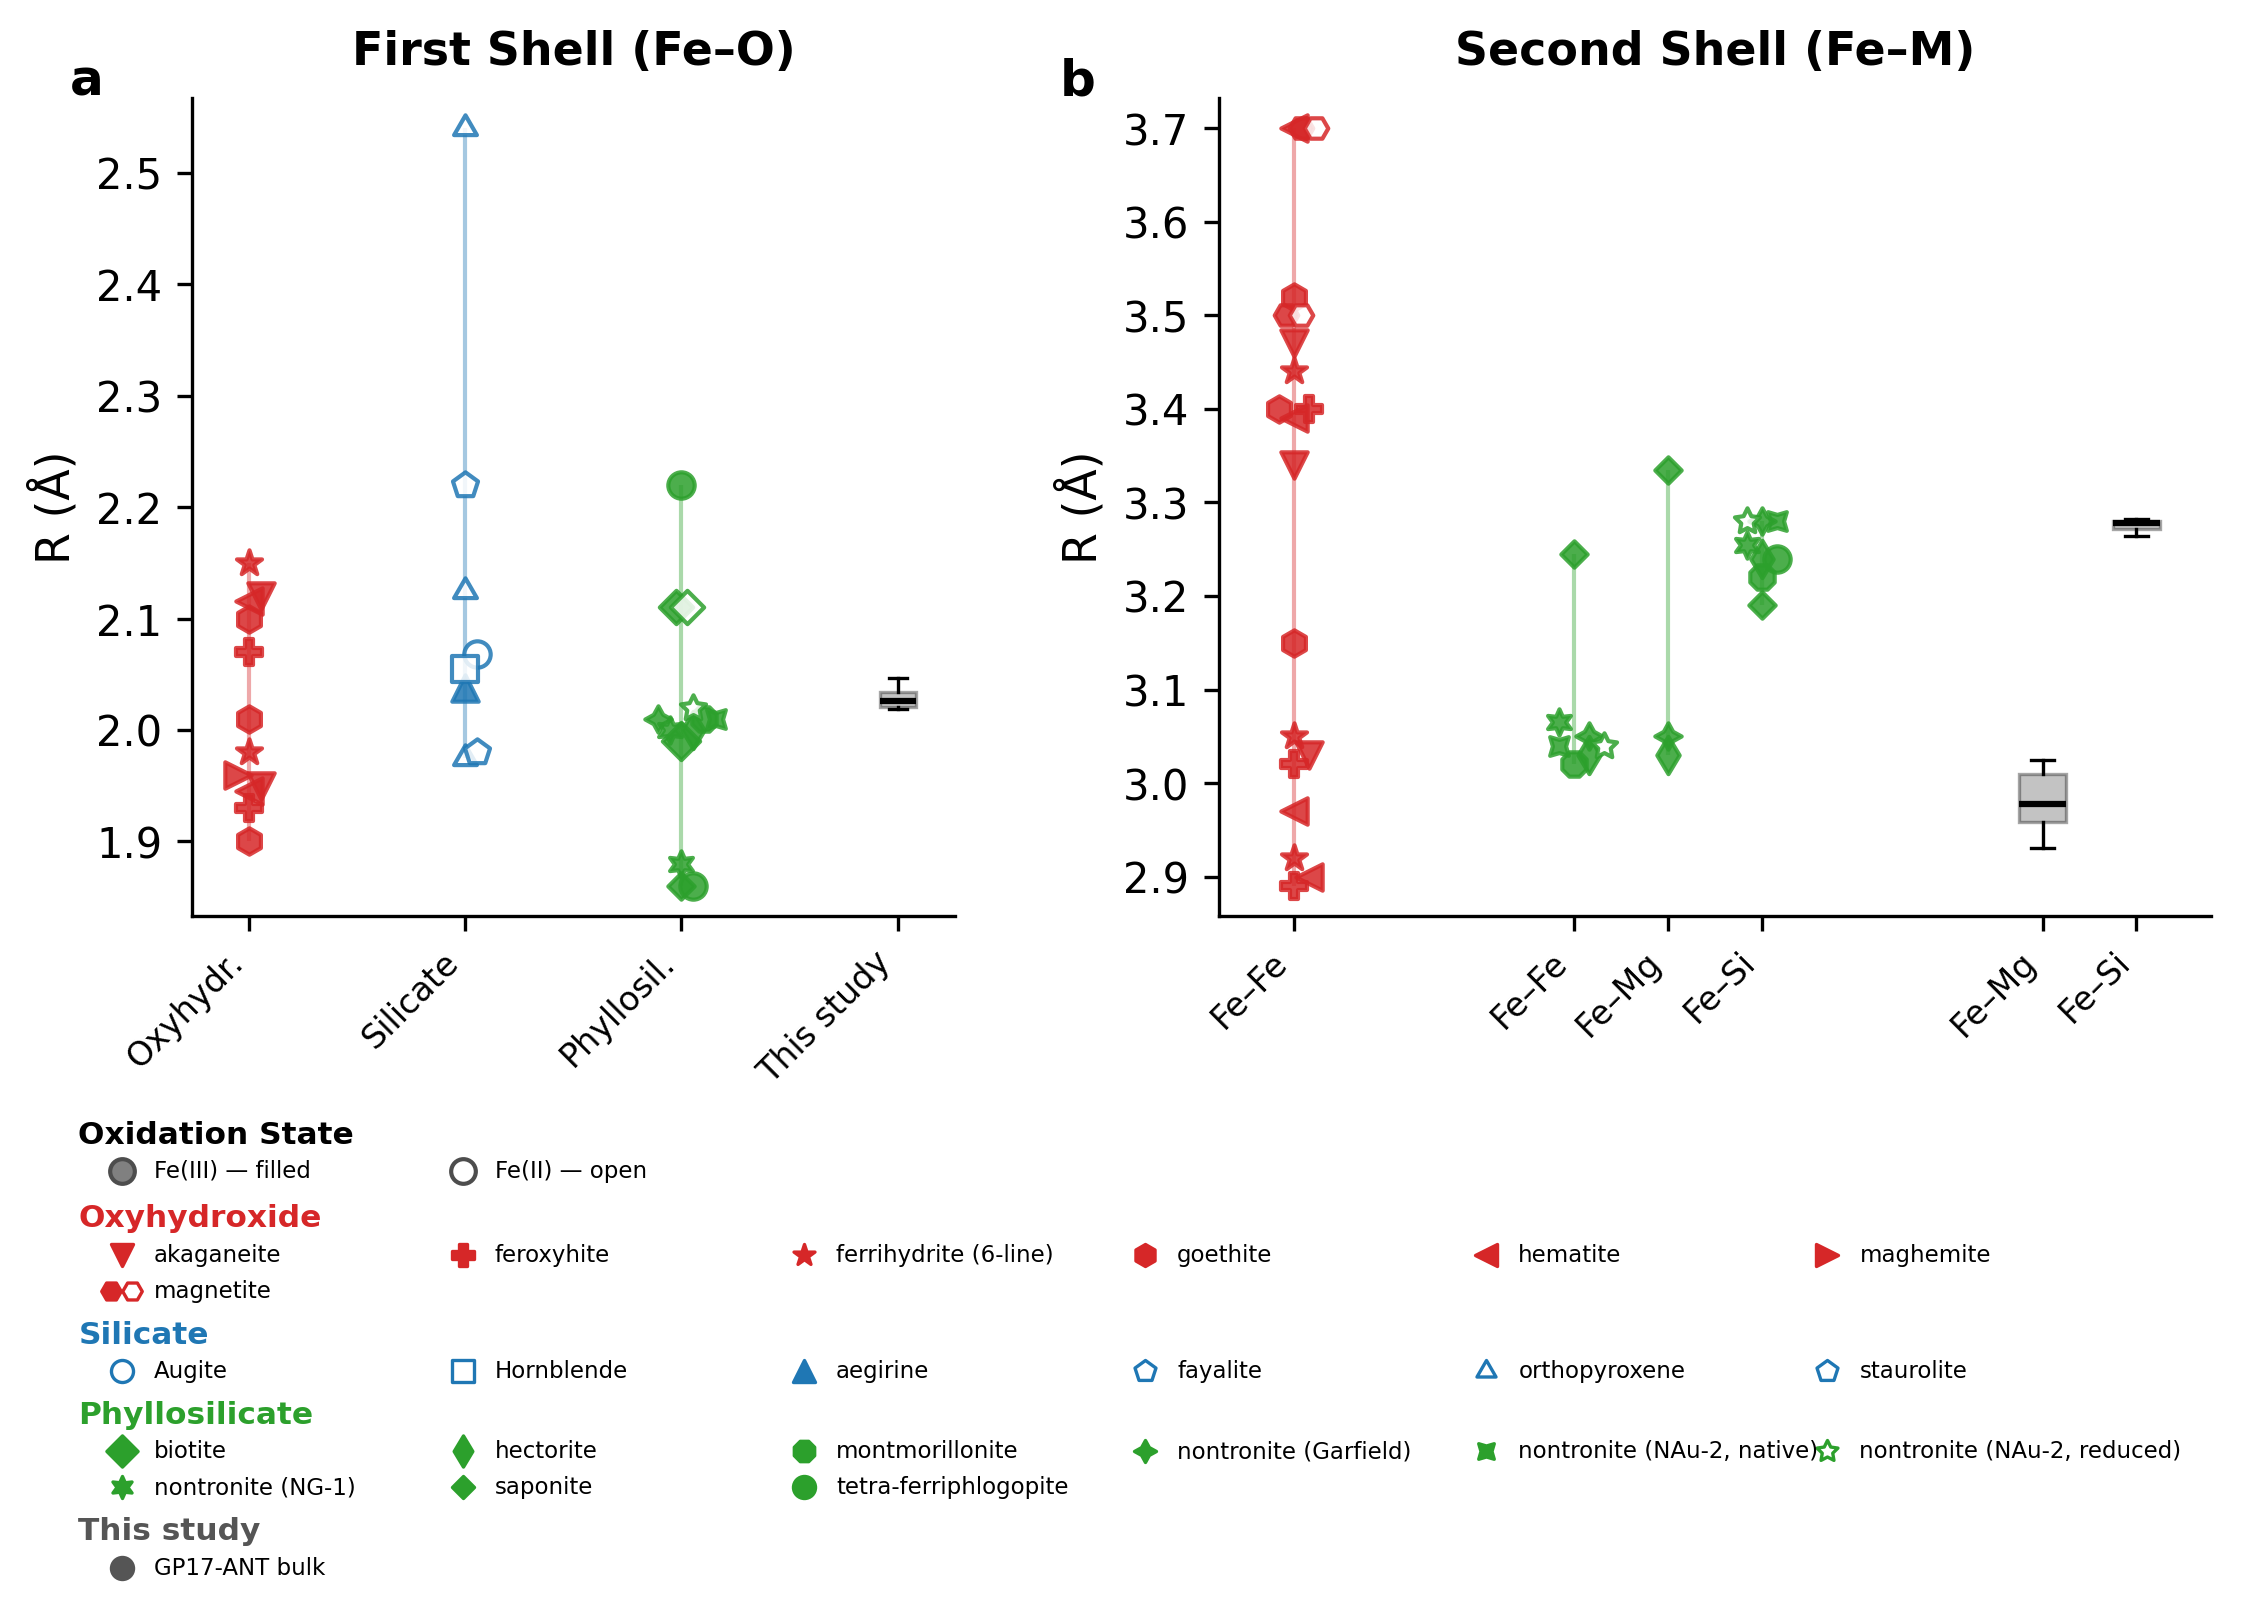

In [9]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(190 / 25.4, 110 / 25.4), dpi=300,
    gridspec_kw={"width_ratios": [1, 1.3]},
)
fig.subplots_adjust(bottom=0.30, wspace=0.30, left=0.08, right=0.98, top=0.93)

make_panel(ax1, first_shell, "First Shell (Fe\u2013O)", use_class_labels=True)
make_panel(ax2, second_shell, "Second Shell (Fe\u2013M)")

# Panel labels
for ax, label in zip((ax1, ax2), ("a", "b")):
    ax.text(-0.16, 1.05, label, transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="top")

# ── Table-style legend ──
cls_groups = defaultdict(list)
seen_display = set()
for a in (ax1, ax2):
    for h, l in zip(*a.get_legend_handles_labels()):
        if l in seen_display:
            continue
        seen_display.add(l)
        row = df_all[df_all["Mineral Name"] == l]
        if row.empty:
            orig = [k for k, v in mineral_display.items() if v == l]
            if orig:
                row = df_all[df_all["Mineral Name"] == orig[0]]
        if row.empty:
            cls_groups["This study"].append((h, l))
        else:
            cls_groups[row["Mineral Class"].iloc[0]].append((h, l))

for cls in cls_groups:
    cls_groups[cls].sort(key=lambda x: x[1])

def _get_oxstate(mname):
    row = df_all[df_all["Mineral Name"] == mname]
    if row.empty:
        orig = [k for k, v in mineral_display.items() if v == mname]
        if orig:
            row = df_all[df_all["Mineral Name"] == orig[0]]
    if row.empty:
        return ""
    return str(row["Fe Oxidation State"].iloc[0])

def _internal_name(display):
    for k, v in mineral_display.items():
        if v == display:
            return k
    return display

legend_ax = fig.add_axes([0.02, -0.06, 0.96, 0.20])
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.axis("off")

ncol = 6
row_height = 0.14
col_width = 0.95 / ncol
y = 0.96

# Oxidation state key
legend_ax.text(0.01, y, "Oxidation State", fontsize=7.5, fontweight="bold", color="k",
               va="center", transform=legend_ax.transAxes)
y -= row_height
ox_items = [
    ("0.5", "0.3", "Fe(III) \u2014 filled"),
    ("white", "0.3", "Fe(II) \u2014 open"),
]
for i, (fc, ec, lbl) in enumerate(ox_items):
    x = 0.03 + i * col_width
    legend_ax.scatter(x, y, marker="o", s=35, facecolors=fc, edgecolors=ec,
                      linewidths=1.0, transform=legend_ax.transAxes, clip_on=False)
    legend_ax.text(x + 0.015, y, lbl, fontsize=5.5, va="center",
                   transform=legend_ax.transAxes)

y -= row_height * 1.3

# Mineral classes
for cls in class_order:
    if cls not in cls_groups:
        continue
    minerals = cls_groups[cls]
    color = class_colors[cls]

    legend_ax.text(0.01, y, cls, fontsize=7.5, fontweight="bold", color=color,
                   va="center", transform=legend_ax.transAxes)
    y -= row_height

    for j, (h, l) in enumerate(minerals):
        col = j % ncol
        if j > 0 and col == 0:
            y -= row_height
        x = 0.03 + col * col_width

        iname = _internal_name(l)
        mk = mineral_markers.get(iname, "o")
        oxst = _get_oxstate(l)

        if "mixed" in oxst.lower():
            legend_ax.scatter(x - 0.005, y, marker=mk, s=22, facecolors=color,
                              edgecolors=color, linewidths=0.8,
                              transform=legend_ax.transAxes, clip_on=False)
            legend_ax.scatter(x + 0.005, y, marker=mk, s=22, facecolors="white",
                              edgecolors=color, linewidths=0.8,
                              transform=legend_ax.transAxes, clip_on=False)
        elif "Fe(II)" in oxst and "Fe(III)" not in oxst:
            legend_ax.scatter(x, y, marker=mk, s=28, facecolors="white",
                              edgecolors=color, linewidths=0.8,
                              transform=legend_ax.transAxes, clip_on=False)
        else:
            legend_ax.scatter(x, y, marker=mk, s=28, facecolors=color,
                              edgecolors=color, linewidths=0.8,
                              transform=legend_ax.transAxes, clip_on=False)

        legend_ax.text(x + 0.015, y, l, fontsize=5.5, va="center",
                       transform=legend_ax.transAxes)

    y -= row_height * 1.2

fig.savefig(FIGURE_DIR / "figure_exafs_distances.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "figure_exafs_distances.pdf", bbox_inches="tight")
print("Saved figure_exafs_distances.png and .pdf")
plt.show()

In [10]:
# Summary tables
print("\u2500\u2500 First Shell (Fe-O) summary \u2500\u2500")
for cls in class_order:
    subset = first_shell[first_shell["Mineral Class"] == cls]
    if subset.empty:
        continue
    print(f"\n  {cls}:")
    for label in sorted(subset["Subshell Label"].unique()):
        vals = subset[subset["Subshell Label"] == label]["R Angstrom"]
        print(f"    {label}: n={len(vals)}, median={vals.median():.3f}, "
              f"range=[{vals.min():.3f}, {vals.max():.3f}]")

print("\n\u2500\u2500 Second Shell (Fe-M) summary \u2500\u2500")
for cls in class_order:
    subset = second_shell[second_shell["Mineral Class"] == cls]
    if subset.empty:
        continue
    print(f"\n  {cls}:")
    for label in sorted(subset["Subshell Label"].unique()):
        vals = subset[subset["Subshell Label"] == label]["R Angstrom"]
        print(f"    {label}: n={len(vals)}, median={vals.median():.3f}, "
              f"range=[{vals.min():.3f}, {vals.max():.3f}]")

── First Shell (Fe-O) summary ──

  Oxyhydroxide:
    Fe–O: n=12, median=1.995, range=[1.900, 2.150]

  Silicate:
    Fe–O: n=8, median=2.062, range=[1.975, 2.540]

  Phyllosilicate:
    Fe–O: n=12, median=2.005, range=[1.860, 2.220]

  This study:
    Fe–O: n=21, median=2.026, range=[2.018, 2.047]

── Second Shell (Fe-M) summary ──

  Oxyhydroxide:
    Fe–Fe: n=18, median=3.365, range=[2.890, 3.700]

  Phyllosilicate:
    Fe–Fe: n=7, median=3.040, range=[3.020, 3.245]
    Fe–Mg: n=3, median=3.050, range=[3.030, 3.335]
    Fe–Si: n=8, median=3.248, range=[3.190, 3.280]

  This study:
    Fe–Mg: n=21, median=2.978, range=[2.930, 3.024]
    Fe–Si: n=21, median=3.278, range=[3.264, 3.282]
